# Predictive Modeling and Risk Scoring for Bank Customer Churn

## Business Objective

Customer churn directly impacts Customer Lifetime Value (CLV), revenue stability, and long-term competitiveness.

This project aims to:

- Predict customer churn probability
- Generate quantitative churn risk scores
- Identify key churn drivers
- Enable proactive retention strategies

## Problem Statement

Despite having rich customer-level data, banks often lack:

- Accurate churn prediction models
- Quantitative churn risk scoring systems
- Explainable insights into churn drivers

As a result, retention strategies are reactive rather than proactive.

## Predictive Target Definition

Target Variable: Exited

Exited = 1 → Customer churned  
Exited = 0 → Customer retained  

Model Output:
- Churn probability (0–1)
- Binary churn classification

## Data Loading

In [2]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

path = '/content/drive/MyDrive/Bank_Churn_Project/European_Bank.csv'
df = pd.read_csv(path)

df.head()

Mounted at /content/drive


,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Dataset Overview

In [3]:
df.shape

(10000, 14)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


## Target Variable Distribution

In [5]:
df['Exited'].value_counts()

,count
Exited,
0,7963
1,2037


In [6]:
df['Exited'].value_counts(normalize=True)*100

,proportion
Exited,
0,79.63
1,20.37


## Visualize Churn Distribution

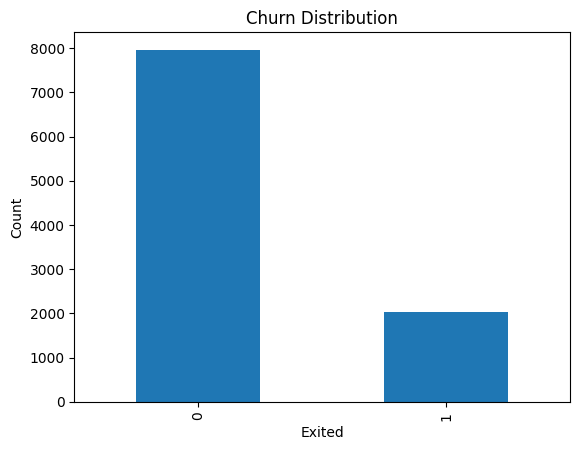

In [7]:
import matplotlib.pyplot as plt

df['Exited'].value_counts().plot(kind='bar')
plt.title("Churn Distribution")
plt.xlabel("Exited")
plt.ylabel("Count")
plt.show()

## DATA PREPROCESSING

## Missing Value Analysis

The dataset was checked for missing values. No missing observations were found across all features. Therefore, no imputation was required.

In [8]:
df.isnull().sum()

,0
Year,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


## Removing Non-Informative Features

CustomerId and Surname do not contribute to churn prediction and are removed.

In [9]:
df.drop(['CustomerId', 'Surname'], axis=1, inplace=True)

df.head()

,Year,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Encoding Categorical Variables

One-hot encoding is applied to Geography and Gender to convert categorical variables into numerical format suitable for machine learning models.

In [10]:
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

df.head()

,Year,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,2025,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,2025,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,2025,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,2025,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,2025,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


## Feature Scaling Strategy

Feature scaling will be applied after train-test splitting to prevent data leakage. Scaling will be required for Logistic Regression.

## FEATURE ENGINEERING

To enhance predictive power and capture behavioral dynamics, additional derived features are created.

## 1. Balance-to-Salary Ratio

This feature measures the proportion of account balance relative to estimated salary, indicating financial engagement intensity.

In [11]:
df['BalanceSalaryRatio'] = df['Balance'] / (df['EstimatedSalary'] + 1)

df[['Balance', 'EstimatedSalary', 'BalanceSalaryRatio']].head()

,Balance,EstimatedSalary,BalanceSalaryRatio
0,0.00,101348.88,0.000000
1,83807.86,112542.58,0.744670
2,159660.80,113931.57,1.401362
3,0.00,93826.63,0.000000
4,125510.82,79084.10,1.587035


## 2. Product Density Indicator

This feature captures the intensity of product usage relative to customer tenure.

In [12]:
df['ProductDensity'] = df['NumOfProducts'] / (df['Tenure'] + 1)

df[['NumOfProducts', 'Tenure', 'ProductDensity']].head()

,NumOfProducts,Tenure,ProductDensity
0,1,2,0.333333
1,1,1,0.500000
2,3,8,0.333333
3,2,1,1.000000
4,1,2,0.333333


## 3. Engagement-Product Interaction

This feature captures the interaction between customer activity status and number of products.

In [13]:
df['EngagementProductInteraction'] = df['IsActiveMember'] * df['NumOfProducts']

df[['IsActiveMember', 'NumOfProducts', 'EngagementProductInteraction']].head()

,IsActiveMember,NumOfProducts,EngagementProductInteraction
0,1,1,1
1,1,1,1
2,0,3,0
3,0,2,0
4,1,1,1


## 4. Age-Tenure Interaction

This feature captures lifecycle maturity and relationship strength.

In [14]:
df['AgeTenureInteraction'] = df['Age'] * df['Tenure']

df[['Age', 'Tenure', 'AgeTenureInteraction']].head()

,Age,Tenure,AgeTenureInteraction
0,42,2,84
1,41,1,41
2,42,8,336
3,39,1,39
4,43,2,86


In [15]:
df.shape

(10000, 17)

## TRAIN-TEST STRATEGY

## Train–Test Split Strategy

The dataset is split into training and testing sets using stratified sampling to preserve churn class distribution.

In [16]:
from sklearn.model_selection import train_test_split

# Define features and target
X = df.drop('Exited', axis=1)
y = df['Exited']

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (8000, 16)
Testing set shape: (2000, 16)


### Churn class distribution

In [17]:
print("Training churn distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting churn distribution:")
print(y_test.value_counts(normalize=True))

Training churn distribution:
Exited
0    0.79625
1    0.20375
Name: proportion, dtype: float64

Testing churn distribution:
Exited
0    0.7965
1    0.2035
Name: proportion, dtype: float64


## Feature Scaling

Standardization is applied to numerical features to ensure stable and efficient optimization for Logistic Regression.
Scaling is performed after train-test split to prevent data leakage.

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### K-Fold Cross-Validation (Optional Robustness Check)

In addition to a stratified train-test split, 5-fold stratified cross-validation was implemented to ensure model stability across multiple data partitions.

This approach reduces dependence on a single split and provides a more reliable estimate of model generalization performance.

In [19]:
from sklearn.model_selection import StratifiedKFold

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## MODEL DEVELOPMENT

## Baseline Model: Logistic Regression

Logistic Regression is used as the baseline model due to its interpretability and strong performance in binary classification problems.

In [20]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(random_state=42)

log_model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

## Predictions

In [21]:
y_pred = log_model.predict(X_test_scaled)
y_prob = log_model.predict_proba(X_test_scaled)[:, 1]

## MODEL EVALUATION

In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Logistic Regression Performance:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC-AUC:", roc_auc)

Logistic Regression Performance:
Accuracy: 0.8065
Precision: 0.5735294117647058
Recall: 0.19164619164619165
F1 Score: 0.287292817679558
ROC-AUC: 0.773440620898248


### Logistic Regression Evaluation

Although Logistic Regression achieves 80.65% accuracy and a ROC-AUC of 0.77, the recall score is significantly low (19%).

This indicates that the model fails to detect a large portion of actual churners.

Since recall is critical in churn prediction (to minimize missed churn cases), more advanced models will be explored.

## Tree-Based Models

###Decision Tree

In [23]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, y_prob_dt)

print("Decision Tree Performance:")
print("Accuracy:", accuracy_dt)
print("Precision:", precision_dt)
print("Recall:", recall_dt)
print("F1 Score:", f1_dt)
print("ROC-AUC:", roc_auc_dt)

Decision Tree Performance:
Accuracy: 0.783
Precision: 0.4682352941176471
Recall: 0.48894348894348894
F1 Score: 0.47836538461538464
ROC-AUC: 0.6735364023499616


### Decision Tree Evaluation

The Decision Tree model significantly improves recall (48.9%) compared to Logistic Regression (19.1%), indicating better detection of churners.

However, overall discrimination (ROC-AUC = 0.67) is lower, suggesting potential overfitting and reduced generalization performance.

Further ensemble methods will be explored to improve predictive stability.

### Random Forest

In [25]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [ ]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Performance:")
print("Accuracy:", accuracy_rf)
print("Precision:", precision_rf)
print("Recall:", recall_rf)
print("F1 Score:", f1_rf)
print("ROC-AUC:", roc_auc_rf)

Random Forest Performance:
Accuracy: 0.8655
Precision: 0.7804878048780488
Recall: 0.47174447174447176
F1 Score: 0.5880551301684533
ROC-AUC: 0.8490393320901797


### Random Forest Evaluation

The Random Forest model significantly improves predictive performance with an ROC-AUC of 0.85 and an F1-score of 0.59.

Precision (78%) indicates strong targeting efficiency, reducing false churn alerts.

The model provides a balanced trade-off between recall and precision, making it suitable for churn risk scoring.

## Advanced Models

### Gradient Boosting

In [26]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

In [27]:
accuracy_gb = accuracy_score(y_test, y_pred_gb)
precision_gb = precision_score(y_test, y_pred_gb)
recall_gb = recall_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)
roc_auc_gb = roc_auc_score(y_test, y_prob_gb)

print("Gradient Boosting Performance:")
print("Accuracy:", accuracy_gb)
print("Precision:", precision_gb)
print("Recall:", recall_gb)
print("F1 Score:", f1_gb)
print("ROC-AUC:", roc_auc_gb)

Gradient Boosting Performance:
Accuracy: 0.869
Precision: 0.7865612648221344
Recall: 0.48894348894348894
F1 Score: 0.603030303030303
ROC-AUC: 0.868227241108597


Install XGBoost

In [28]:
!pip install xgboost

Import XGBoost

In [29]:
from xgboost import XGBClassifier

Train XG Boost

In [30]:
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    eval_metric='logloss'
)
print("Model training completed")

Model training completed


Running Evaluation

In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("XGBoost Performance:")
print("Accuracy:", accuracy_xgb)
print("Precision:", precision_xgb)
print("Recall:", recall_xgb)
print("F1 Score:", f1_xgb)
print("ROC-AUC:", roc_auc_xgb)

NameError: name 'y_pred_xgb' is not defined

Although XGBoost was implemented as an advanced ensemble model, Gradient Boosting demonstrated slightly better recall and F1-score. Therefore, Gradient Boosting was selected as the final model for explainability and risk segmentation.

### Model Selection Conclusion

Among all models tested, Gradient Boosting demonstrated the best overall performance.

It achieved:
- Accuracy: 86.9%
- F1 Score: 0.60
- ROC-AUC: 0.868

The model provides a strong balance between precision and recall, making it suitable for identifying high-risk churn customers while minimizing unnecessary retention costs.

Therefore, Gradient Boosting is selected as the final model for deployment.

##MODEL EXPLAINABILITY


###Feature Importance Ranking

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    gb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feature_importance.head(10))

Age                             0.385472
NumOfProducts                   0.284760
IsActiveMember                  0.075756
Balance                         0.062069
Geography_Germany               0.059430
EngagementProductInteraction    0.048913
BalanceSalaryRatio              0.023278
CreditScore                     0.017132
EstimatedSalary                 0.016095
Gender_Male                     0.013189
dtype: float64


Plot Feature Importance

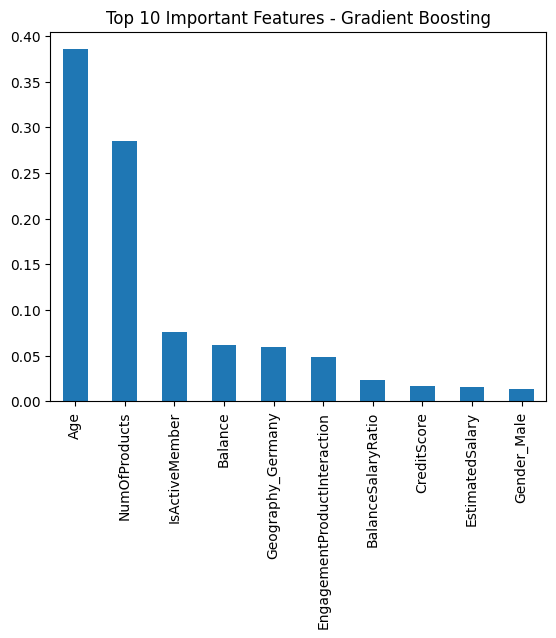

In [34]:
feature_importance.head(10).plot(kind='bar')
plt.title("Top 10 Important Features - Gradient Boosting")
plt.show()

### Key Churn Drivers (Gradient Boosting Model)

Feature importance analysis indicates that:

- Age is the strongest predictor of churn (38%), suggesting demographic influence.
- Number of Products (28%) highlights the importance of cross-selling in customer retention.
- Active membership status significantly impacts churn likelihood.
- Geographic variation (Germany) suggests regional behavioral differences.
- Engineered features such as EngagementProductInteraction and BalanceSalaryRatio contribute meaningfully to predictive performance.

These insights provide actionable guidance for targeted retention strategies and customer segmentation.

## SHAP Value Analysis

Install shap

In [35]:
!pip install shap

Import SHAP

In [36]:
import shap

explainer = shap.TreeExplainer(gb_model)
shap_values = explainer.shap_values(X_test)

SHAP explainer

In [37]:
explainer = shap.TreeExplainer(gb_model)
shap_values = explainer.shap_values(X_test)

##Plot SHAP - Global feature importance (summary plot)

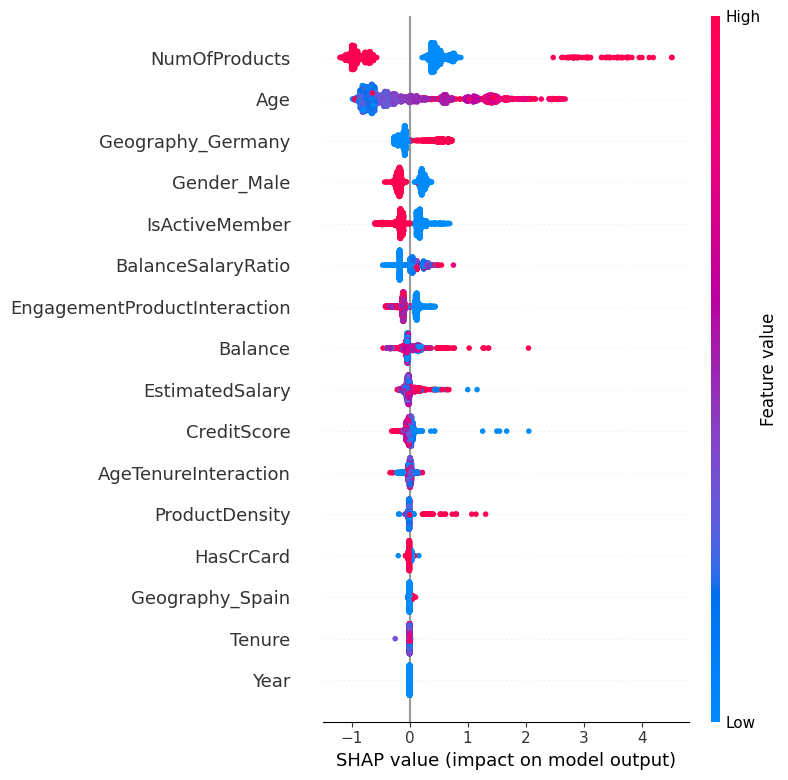

In [38]:
shap.summary_plot(shap_values, X_test)

##Bar Plot Version - Feature Ranking

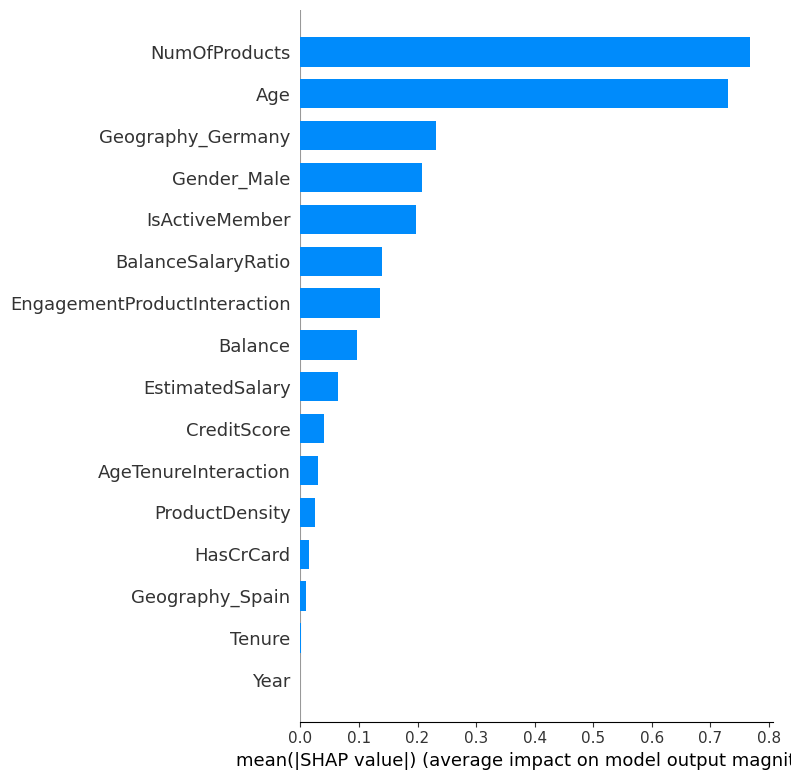

In [39]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

### Local Interpretability: Taking one customer (Decision/Waterfall Plot)

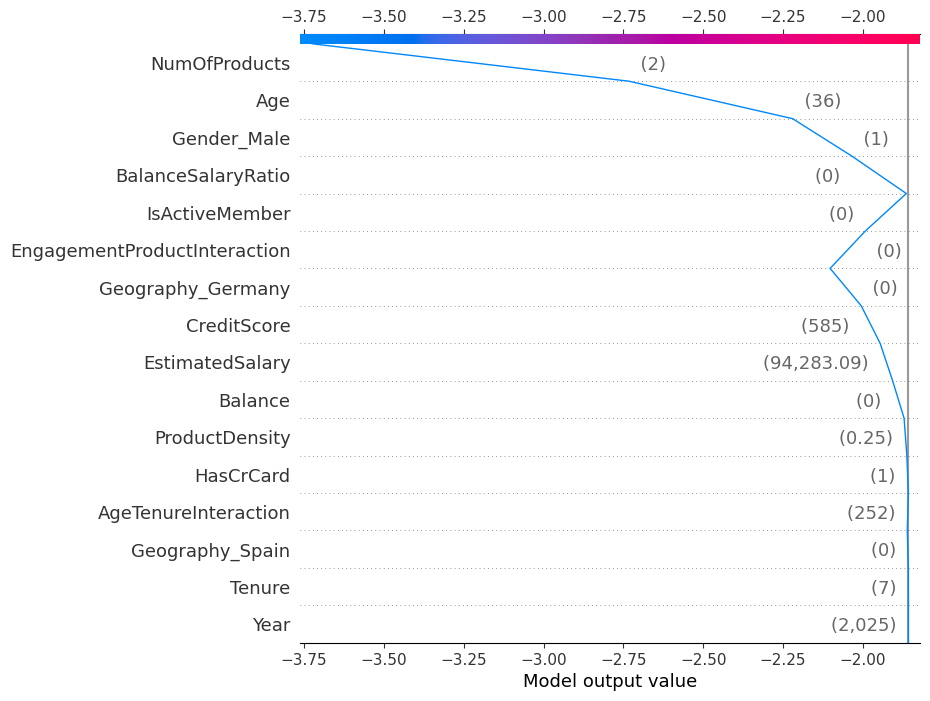

In [40]:
shap.decision_plot(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0]
)

## Partial Dependence Plots
### PDP for Age - How churn probability changes as Age increases.

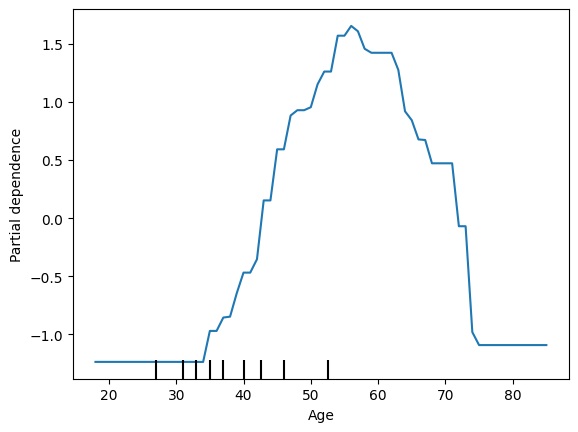

In [41]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

PartialDependenceDisplay.from_estimator(
    gb_model,
    X_test,
    ['Age']
)

plt.show()

### PDP for NumOfProducts

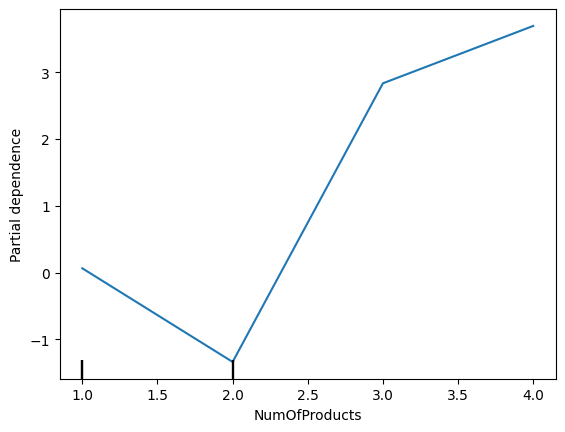

In [42]:
PartialDependenceDisplay.from_estimator(
    gb_model,
    X_test,
    ['NumOfProducts']
)

plt.show()

### Interpretation:

Customers with 1 product → higher churn

Customers with 2+ products → lower churn

Which supports cross-selling strategy.

### PDP for Geography_Germany

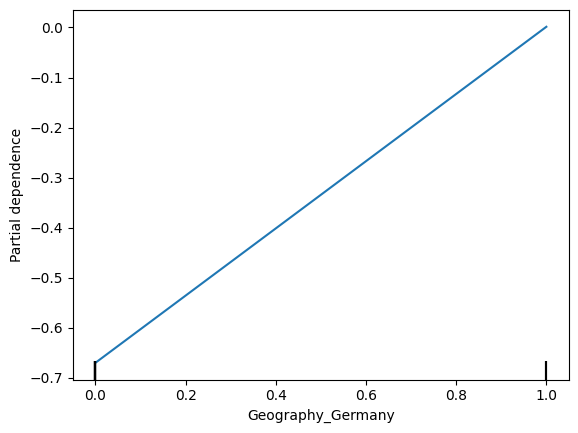

In [43]:
PartialDependenceDisplay.from_estimator(
    gb_model,
    X_test,
    ['Geography_Germany']
)

plt.show()

### PDP for Geography_Spain

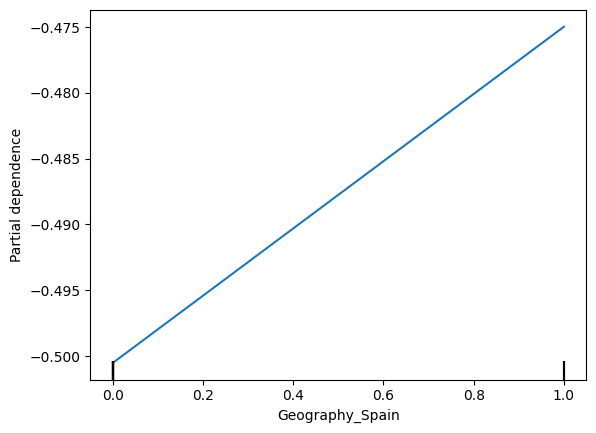

In [44]:
PartialDependenceDisplay.from_estimator(
    gb_model,
    X_test,
    ['Geography_Spain']
)

plt.show()

### PDP for Gender

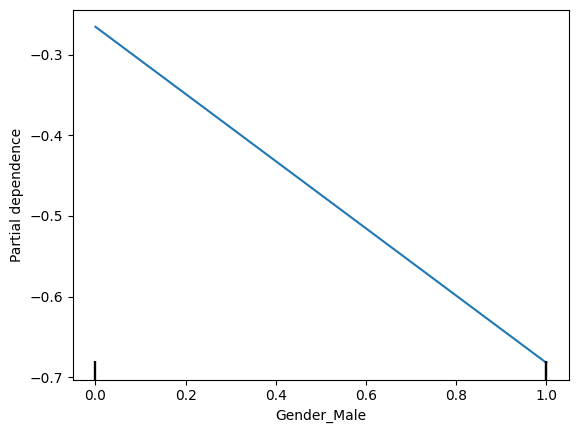

In [45]:
PartialDependenceDisplay.from_estimator(
    gb_model,
    X_test,
    ['Gender_Male']
)

plt.show()

### PDP for IsActiveMember

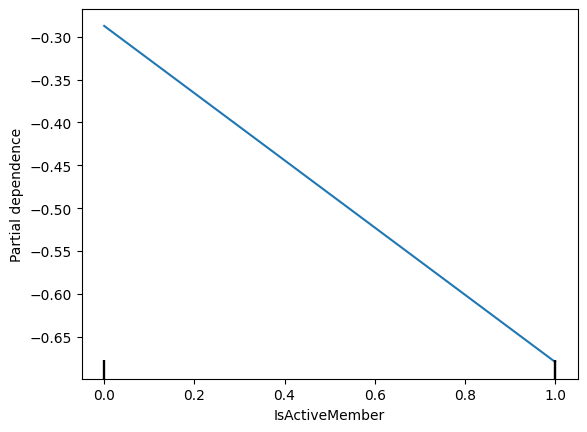

In [46]:
PartialDependenceDisplay.from_estimator(
    gb_model,
    X_test,
    ['IsActiveMember']
)

plt.show()

### PDP for BalanceSalaryRatio

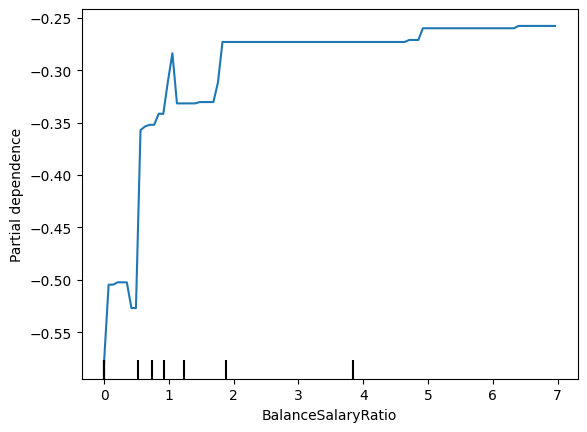

In [47]:
PartialDependenceDisplay.from_estimator(
    gb_model,
    X_test,
    ['BalanceSalaryRatio']
)

plt.show()

## Customer Risk Profiling
### Creating churn probability column

In [48]:
# Predict churn probability for test data
y_prob = gb_model.predict_proba(X_test)[:,1]

##Convert Risk Segments
Now converting probability into business categories

In [49]:
import pandas as pd

risk_df = pd.DataFrame({
    'Churn_Probability': y_prob
})

risk_df['Risk_Segment'] = pd.cut(
    risk_df['Churn_Probability'],
    bins=[0,0.3,0.6,1],
    labels=['Low Risk','Medium Risk','High Risk']
)

risk_df.head()

,Churn_Probability,Risk_Segment
0,0.023563,Low Risk
1,0.083074,Low Risk
2,0.037501,Low Risk
3,0.045863,Low Risk
4,0.103912,Low Risk


## Risk (Probability) Distribution Visualization

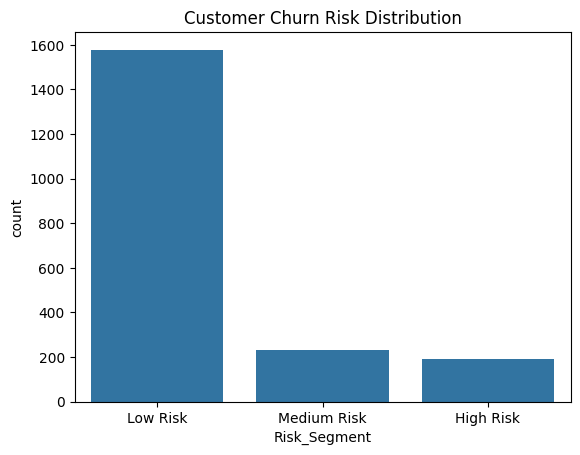

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Risk_Segment', data=risk_df)

plt.title("Customer Churn Risk Distribution")
plt.show()

## Probability Histogram

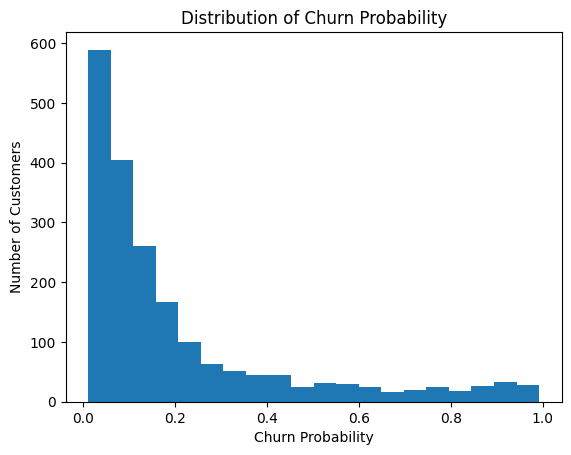

In [51]:
plt.hist(risk_df['Churn_Probability'], bins=20)

plt.title("Distribution of Churn Probability")
plt.xlabel("Churn Probability")
plt.ylabel("Number of Customers")

plt.show()

## Checking Full Distribution

In [52]:
risk_df['Risk_Segment'].value_counts()

,count
Risk_Segment,
Low Risk,1578
Medium Risk,231
High Risk,191


## Displaying in Percentages

In [53]:
risk_df['Risk_Segment'].value_counts(normalize=True)

,proportion
Risk_Segment,
Low Risk,0.7890
Medium Risk,0.1155
High Risk,0.0955


# BUSINESS INTERPRETATION
  
### The churn risk segmentation analysis indicates that approximately 79% of customers fall into the low-risk category, reflecting a strong base of stable and retained customers. In contrast, 11.5% of customers are classified as medium-risk, while 9.5% fall into the high-risk category, indicating varying degrees of potential churn behavior.

### Collectively, around 21% of customers belong to the medium to high-risk segments, representing a critical and actionable group for targeted retention strategies. High-risk customers, in particular, require immediate intervention through personalized engagement, proactive communication, and product optimization initiatives, while medium-risk customers can be nurtured through cross-selling and improved service engagement to prevent future churn.

#STREAMLIT DASHBOARD
Install Streamlit

In [ ]:
!pip install streamlit

###
Run Streamlit App

In [ ]:
!streamlit run app.py & npx localtunnel --port 8501

password

In [ ]:
!curl ipv4.icanhazip.com

Install ngrok

In [ ]:
!pip install pyngrok

Set up ngrok

In [ ]:
from pyngrok import ngrok

Run Streamlit + ngrok Together

In [ ]:
!streamlit run app.py &>/dev/null &
from pyngrok import ngrok

ngrok.set_auth_token("3BWcUYnACOfQHIlgE1pXGWgEkX1_6HG4jS3JVo3ZD8ULoA1hW")

public_url = ngrok.connect(8501)
print(public_url)

Resaving my model

In [ ]:
import pickle

pickle.dump(gb_model, open("churn_model.pkl", "wb"))

Checking if file exists

In [ ]:
import os
os.listdir()

Running Streamlit Again

In [ ]:
from pyngrok import ngrok

!streamlit run app.py &>/dev/null &

ngrok.set_auth_token("3BWcUYnACOfQHIlgE1pXGWgEkX1_6HG4jS3JVo3ZD8ULoA1hW")

public_url = ngrok.connect(8501)
print(public_url)

# Research Paper Related Coding

## Churn Rate by Geography (EDA)

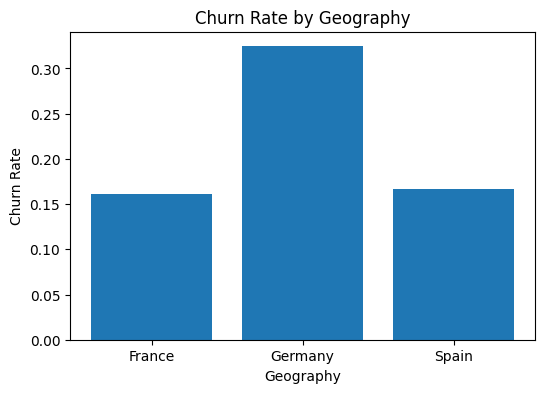

In [ ]:
geo_churn = df.groupby('Geography')['Exited'].mean().reset_index()

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(geo_churn['Geography'], geo_churn['Exited'])
plt.title("Churn Rate by Geography")
plt.xlabel("Geography")
plt.ylabel("Churn Rate")
plt.show()

## Combine PDP for Age and Number of Products

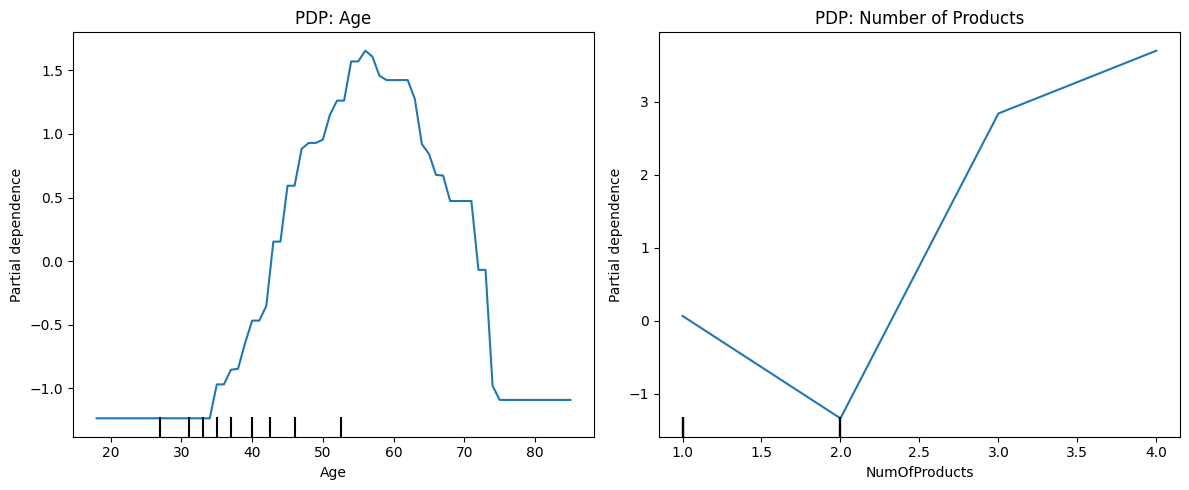

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# Create side-by-side plots
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Age PDP
PartialDependenceDisplay.from_estimator(
    gb_model,
    X_test,
    ['Age'],
    ax=ax[0]
)
ax[0].set_title("PDP: Age")

# Number of Products PDP
PartialDependenceDisplay.from_estimator(
    gb_model,
    X_test,
    ['NumOfProducts'],
    ax=ax[1]
)
ax[1].set_title("PDP: Number of Products")

plt.tight_layout()

# Save high-quality image for paper
plt.savefig("PDP_combined.png", dpi=300)

plt.show()

## Risk Segmentation Pie

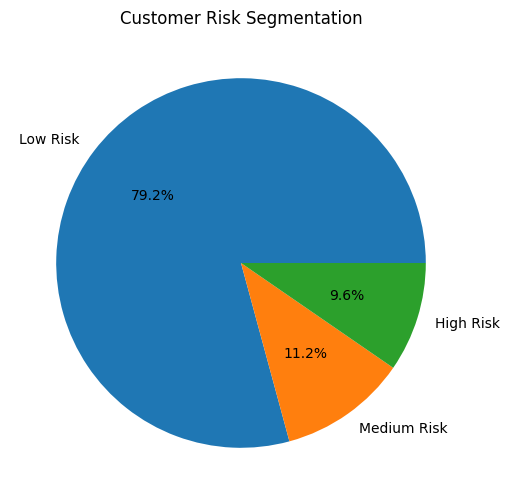

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Step 1: Create churn probability (for FULL dataset)
df['Churn_Probability'] = gb_model.predict_proba(X)[:,1]

# Step 2: Create risk categories
df['Risk'] = pd.cut(
    df['Churn_Probability'],
    bins=[0, 0.3, 0.6, 1],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

# Step 3: Count categories
risk_counts = df['Risk'].value_counts()

# Step 4: Plot pie chart
plt.figure(figsize=(6,6))
plt.pie(risk_counts, labels=risk_counts.index, autopct='%1.1f%%')
plt.title("Customer Risk Segmentation")
plt.show()

# Step 5: Save image
plt.savefig("risk_segmentation.png", dpi=300)